第 3 章KNN算法

## 3.1.1工作原理
计算距离：计算待分类样本与训练集中每个样本的距离。
选择K个近邻：根据计算的距离，选择距离最近的K个样本。
投票或平均：
分类任务：统计K个近邻各类别的数量，将待分类样本归为数量最多的类别。
回归任务：取K个近邻的平均值作为预测结果。

## 3.1.2关键参数
距离度量方法：选择合适的距离度量方法，常见的有欧氏距离、曼哈顿距离、切比雪夫距离、闵可夫斯基距离等。
K值：K值的选择对结果影响很大。K值过小容易过拟合，K值过大则可能欠拟合。

## 3.1.3优缺点
KNN优点：
简单直观，易于理解和实现。
无需训练过程，直接利用训练数据进行预测。
KNN缺点：
计算量大，尤其是训练集较大时。
对噪声数据较敏感。

## 3.1.4API使用

In [5]:
from sklearn.neighbors import KNeighborsClassifier
import  numpy as np
import matplotlib.pyplot as plt

In [19]:

# 利用 KNN（K近邻） 算法对给定的四个点进行训练，然后预测新点 (4,9) 的类别，最后用散点图可视化训练点与预测点的颜色
# 准备数据
# X = [[2, 1], [3, 1], [1, 4], [2, 6]]# 特征
# y = [0, 0, 1, 1]# 标签
# 创建特征矩阵 X 和标签向量 y
X = np.array([[2, 1], [3, 1], [1, 4], [2, 6]])
y = np.array([0, 0, 1, 1])
# 定义KNN分类模型
# 初始化一个 KNN 分类器，n_neighbors=2 表示取最近的 2 个邻居进行投票。
# 用 X 和 y 训练模型。
knn = KNeighborsClassifier(n_neighbors=2)# KNN分类模型，K值为2

knn.fit(X, y) # 模型训练
# 定义待预测点 (4,9)。
# 调用 predict 预测其类别，结果存入 x_class（是一个 Numpy 数组，如 array([0]) 或 array([1])）。
# 打印预测值。
x = np.array([[4,9]])
x_class = knn.predict([[4, 9]])
print(x_class)

[1]


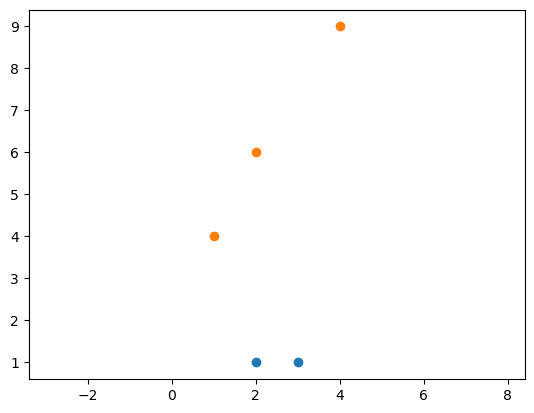

In [20]:
# 可视化
fig, ax = plt.subplots()
ax.axis('equal')
# 利用布尔索引将两类点分开

X1 = X[y==0]
X2 = X[y==1]
# 定义不同的颜色，画两组点
# 若预测为 1，新点颜色为 colors[0]（蓝色）—— 这与训练集中标签 1 的点颜色（橙色）不一致。
# 若预测为 0，新点颜色为 colors[1]（橙色）—— 又与标签 0 的点颜色（蓝色）不一致。
colors = ['C0', 'C1']
plt.scatter(X1[:, 0], X1[:, 1], c=colors[0])
plt.scatter(X2[:, 0], X2[:, 1], c=colors[1])
# 新的点颜色
x_color = colors[1] if x_class == 1 else colors[0]
plt.scatter(x[:, 0], x[:, 1], c=x_color)
plt.show()

[1]


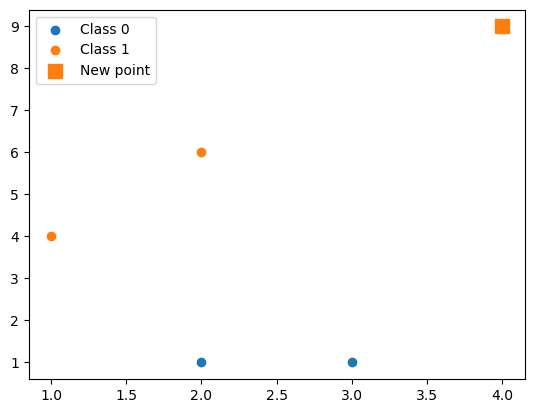

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

X = np.array([[2, 1], [3, 1], [1, 4], [2, 6]])
y = np.array([0, 0, 1, 1])

knn = KNeighborsClassifier(n_neighbors=2)
knn.fit(X, y)

x = np.array([[4, 9]])
x_class = knn.predict(x)          # 直接使用 x
print(x_class)                    # 输出 array([1]) 或 array([0])

# 可视化
X1 = X[y == 0]
X2 = X[y == 1]
colors = ['C0', 'C1']
plt.scatter(X1[:, 0], X1[:, 1], c=colors[0], label='Class 0')
plt.scatter(X2[:, 0], X2[:, 1], c=colors[1], label='Class 1')

# 根据预测结果选择颜色（与对应类别颜色一致）
if x_class[0] == 1:               # 取出标量进行比较
    x_color = colors[1]
else:
    x_color = colors[0]

plt.scatter(x[:, 0], x[:, 1], c=x_color, marker='s', s=100, label='New point')
plt.legend()
plt.show()